# Data Introduction
## Files Description

- application_{train|test}.csv
    - This is the main table, broken into two files for Train (with TARGET) and Test (without TARGET).
    - Static data for all applications. One row represents one loan in our data sample.
- bureau.csv
    - All client's previous credits provided by other financial institutions that were reported to Credit Bureau (for clients who have a loan in our sample). 
    - For every loan in our sample, there are as many rows as number of credits the client had in Credit Bureau before the application date.
- bureau_balance.csv
    - Monthly balances of previous credits in Credit Bureau.
    - This table has one row for each month of history of every previous credit reported to Credit Bureau – i.e the table has (#loans in sample * # of relative previous credits * # of months where we have some history observable for the previous credits) rows.
- POS_CASH_balance.csv
    - Monthly balance snapshots of previous POS (point of sales - điểm bán hàng) and cash loans that the applicant had with Home Credit. Đại khái có thể hiểu là các giao dịch chi tiêu sử dụng các khoản vay của Home Credit.
    - This table has one row for each month of history of every previous credit in Home Credit (consumer credit and cash loans) related to loans in our sample – i.e. the table has (#loans in sample * # of relative previous credits * # of months in which we have some history observable for the previous credits) rows.
- credit_card_balance.csv
    - Monthly balance snapshots of previous credit cards that the applicant has with Home Credit.
    - This table has one row for each month of history of every previous credit in Home Credit (consumer credit and cash loans) related to loans in our sample – i.e. the table has (#loans in sample * # of relative previous credit cards * # of months where we have some history observable for the previous credit card) rows.
- previous_application.csv
    - All previous applications for Home Credit loans of clients who have loans in our sample.
    - There is one row for each previous application related to loans in our data sample.
- installments_payments.csv
    - Repayment history for the previously disbursed (đã giải ngân - kiểu là chấp nhận cho vay) credits in Home Credit related to the loans in our sample.
    - There is a) one row for every payment that was made plus b) one row each for missed payment.
    - One row is equivalent to one payment of one instalment (kỳ trả góp) OR one instalment (kỳ trả góp) corresponding to one payment of one previous Home Credit credit related to loans in our sample. Nói chung là thông tin cho 1 kỳ trả góp
- HomeCredit_columns_description.csv: This file contains descriptions for the columns in the various data files.

## Data Schema

Going from top to bottom, the relationships are all one-to-many.

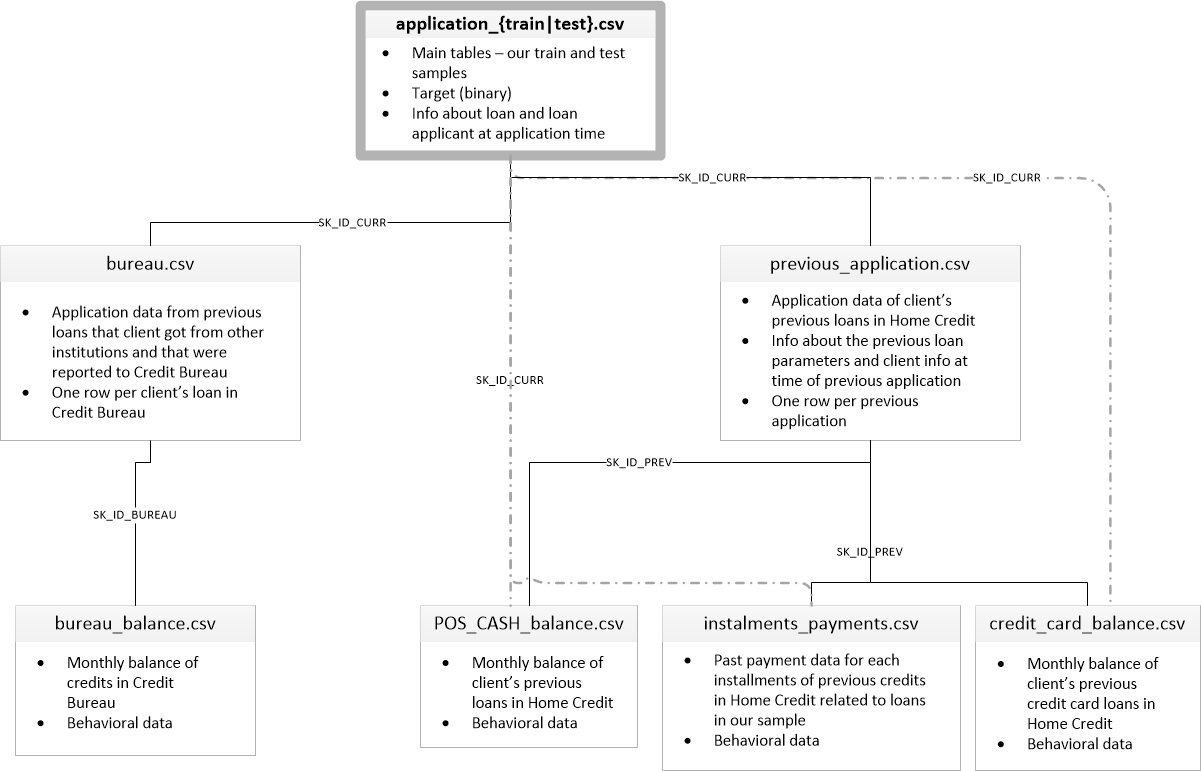

# EDA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Relationships between tables

In [2]:
application_train = pd.read_csv('data/application_train.csv')
application_test = pd.read_csv('data/application_test.csv')
bureau = pd.read_csv('data/bureau.csv')
bureau_balance = pd.read_csv('data/bureau_balance.csv')
previous_application = pd.read_csv('data/previous_application.csv')
pos_cash = pd.read_csv('data/POS_CASH_balance.csv')
instalments = pd.read_csv('data/installments_payments.csv')
credit_card_balance = pd.read_csv('data/credit_card_balance.csv')

KeyboardInterrupt: 

In [ ]:
# application_{train|test} vs bureau
first_train_id = application_test.iloc[0]['SK_ID_CURR']
bureau.groupby('SK_ID_CURR')['SK_ID_BUREAU'].count().head()

# bureau vs bureau_balance
bureau_balance.groupby('SK_ID_BUREAU')['MONTHS_BALANCE'].count()

# application vs pos_cash
pos_cash.groupby(['SK_ID_CURR'])['SK_ID_PREV'].count()

# application vs previous_application
previous_application.groupby('SK_ID_CURR')['SK_ID_PREV'].count()

SK_ID_CURR
100001    1
100002    1
100003    3
100004    1
100005    2
         ..
456251    1
456252    1
456253    2
456254    2
456255    8
Name: SK_ID_PREV, Length: 338857, dtype: int64

## application_{train|test}.csv

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

application_train = pd.read_csv('data/application_train.csv')
application_test = pd.read_csv('data/application_test.csv')

print(application_train.columns.tolist())

['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'OWN_CAR_AGE', 'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY', 'WEEKDAY_APPR_PROCESS_START', 'HOUR_APPR_PROCESS_START', 'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY', 'ORGANIZATION_TYPE', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'YEARS_BEGINEXPLUATATION_AVG', 'YEARS_BUILD_AVG', 'COMMONAREA_AVG', 'ELE

In [2]:
pd.set_option('display.max_rows', None)
application_train.dtypes

SK_ID_CURR                        int64
TARGET                            int64
NAME_CONTRACT_TYPE                  str
CODE_GENDER                         str
FLAG_OWN_CAR                        str
FLAG_OWN_REALTY                     str
CNT_CHILDREN                      int64
AMT_INCOME_TOTAL                float64
AMT_CREDIT                      float64
AMT_ANNUITY                     float64
AMT_GOODS_PRICE                 float64
NAME_TYPE_SUITE                     str
NAME_INCOME_TYPE                    str
NAME_EDUCATION_TYPE                 str
NAME_FAMILY_STATUS                  str
NAME_HOUSING_TYPE                   str
REGION_POPULATION_RELATIVE      float64
DAYS_BIRTH                        int64
DAYS_EMPLOYED                     int64
DAYS_REGISTRATION               float64
DAYS_ID_PUBLISH                   int64
OWN_CAR_AGE                     float64
FLAG_MOBIL                        int64
FLAG_EMP_PHONE                    int64
FLAG_WORK_PHONE                   int64


### String columns

In [3]:
str_cols = application_train.dtypes[application_train.dtypes == 'str'].index.tolist()
str_cols

['NAME_CONTRACT_TYPE',
 'CODE_GENDER',
 'FLAG_OWN_CAR',
 'FLAG_OWN_REALTY',
 'NAME_TYPE_SUITE',
 'NAME_INCOME_TYPE',
 'NAME_EDUCATION_TYPE',
 'NAME_FAMILY_STATUS',
 'NAME_HOUSING_TYPE',
 'OCCUPATION_TYPE',
 'WEEKDAY_APPR_PROCESS_START',
 'ORGANIZATION_TYPE',
 'FONDKAPREMONT_MODE',
 'HOUSETYPE_MODE',
 'WALLSMATERIAL_MODE',
 'EMERGENCYSTATE_MODE']

In [4]:
num_rows = application_train.shape[0]

for col in str_cols:
    print(f'Column: {col}')
    print(f'NaN values: {application_train[col].isna().sum() / num_rows} ({application_train[col].isna().sum()} / {num_rows})')
    print(f'Number of unique values: {application_train[col].nunique()}')
    print(f'Unique values: {application_train[col].unique().tolist()}')
    # print(application_train[col].value_counts())
    print('------------------------')

Column: NAME_CONTRACT_TYPE
NaN values: 0.0 (0 / 307511)
Number of unique values: 2
Unique values: ['Cash loans', 'Revolving loans']
------------------------
Column: CODE_GENDER
NaN values: 0.0 (0 / 307511)
Number of unique values: 3
Unique values: ['M', 'F', 'XNA']
------------------------
Column: FLAG_OWN_CAR
NaN values: 0.0 (0 / 307511)
Number of unique values: 2
Unique values: ['N', 'Y']
------------------------
Column: FLAG_OWN_REALTY
NaN values: 0.0 (0 / 307511)
Number of unique values: 2
Unique values: ['Y', 'N']
------------------------
Column: NAME_TYPE_SUITE
NaN values: 0.004201475719567756 (1292 / 307511)
Number of unique values: 7
Unique values: ['Unaccompanied', 'Family', 'Spouse, partner', 'Children', 'Other_A', nan, 'Other_B', 'Group of people']
------------------------
Column: NAME_INCOME_TYPE
NaN values: 0.0 (0 / 307511)
Number of unique values: 8
Unique values: ['Working', 'State servant', 'Commercial associate', 'Pensioner', 'Unemployed', 'Student', 'Businessman', 'Ma

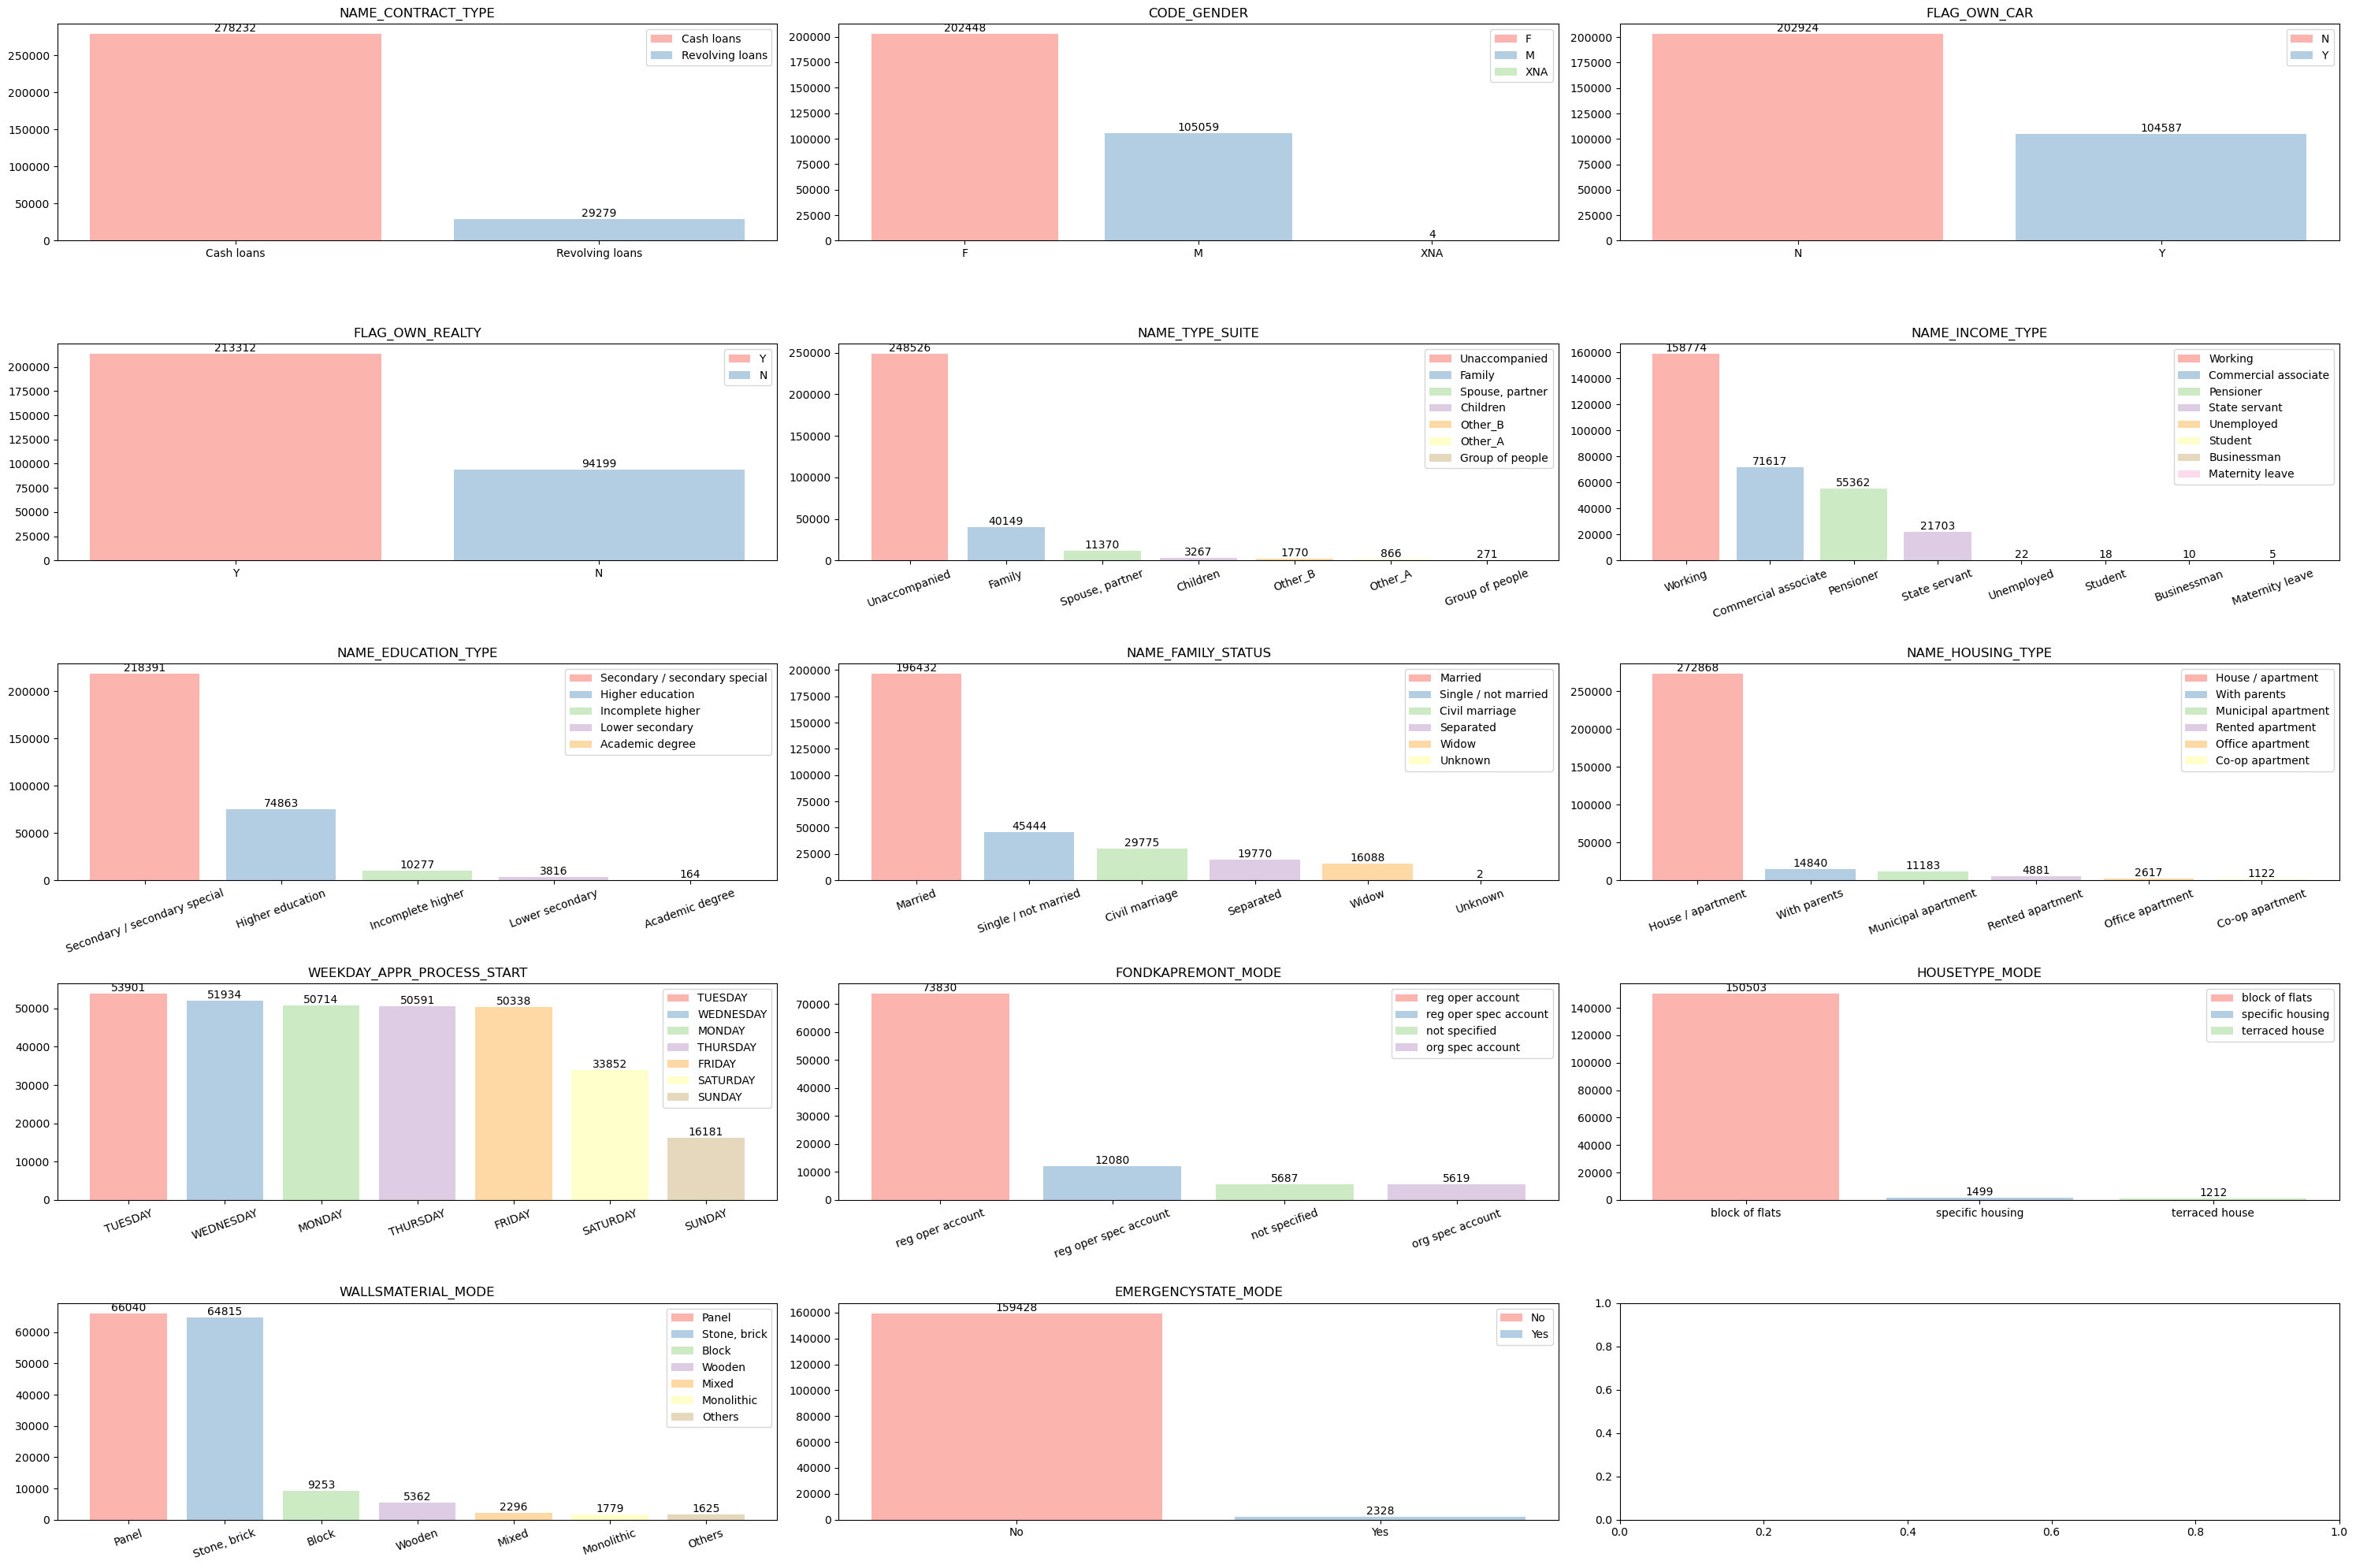

In [5]:
draw_str_cols = str_cols.copy()
draw_str_cols.remove('OCCUPATION_TYPE')
draw_str_cols.remove('ORGANIZATION_TYPE')

fig, ax = plt.subplots(5, 3, figsize=(30, 20))
cmap = plt.get_cmap('Pastel1')

for i, col in enumerate(draw_str_cols):
    col_counts = application_train[col].value_counts()
    bar_colors = [cmap(i) for i in np.arange(len(col_counts))]
    current_ax = ax[i // 3, i % 3].bar(col_counts.index, col_counts.values, color=bar_colors)
    ax[i // 3, i % 3].bar_label(current_ax)
    ax[i // 3, i % 3].set_title(col)
    ax[i // 3, i % 3].legend(current_ax, col_counts.index)
    if len(col_counts.index) > 3:
        ax[i // 3, i % 3].tick_params(axis='x', rotation=20)
    # print(col_counts.index)

plt.tight_layout()
plt.show()

In [6]:
col_des = pd.read_csv(
    'data/HomeCredit_columns_description.csv',
    # sep=';',
    encoding='latin1'
)
print(col_des.columns)
for col in str_cols:
    if application_train[col].isna().sum() > 0:
        print(f'Column: {col}')
        print(f'Description: {col_des[col_des["Row"] == col]["Description"].iloc[0]}')
        print(f'NaN values: {application_train[col].isna().sum() / num_rows} ({application_train[col].isna().sum()} / {num_rows})')
        print('------------------------')

Index(['Unnamed: 0', 'Table', 'Row', 'Description', 'Special'], dtype='str')
Column: NAME_TYPE_SUITE
Description: Who was accompanying client when he was applying for the loan
NaN values: 0.004201475719567756 (1292 / 307511)
------------------------
Column: OCCUPATION_TYPE
Description: What kind of occupation does the client have
NaN values: 0.31345545362604915 (96391 / 307511)
------------------------
Column: FONDKAPREMONT_MODE
Description: Normalized information about building where the client lives, What is average (_AVG suffix), modus (_MODE suffix), median (_MEDI suffix) apartment size, common area, living area, age of building, number of elevators, number of entrances, state of the building, number of floor
NaN values: 0.6838617155158677 (210295 / 307511)
------------------------
Column: HOUSETYPE_MODE
Description: Normalized information about building where the client lives, What is average (_AVG suffix), modus (_MODE suffix), median (_MEDI suffix) apartment size, common area, l

### Int columns

In [7]:
int_cols = application_train.dtypes[application_train.dtypes == 'int64'].index.tolist()
int_cols

['SK_ID_CURR',
 'TARGET',
 'CNT_CHILDREN',
 'DAYS_BIRTH',
 'DAYS_EMPLOYED',
 'DAYS_ID_PUBLISH',
 'FLAG_MOBIL',
 'FLAG_EMP_PHONE',
 'FLAG_WORK_PHONE',
 'FLAG_CONT_MOBILE',
 'FLAG_PHONE',
 'FLAG_EMAIL',
 'REGION_RATING_CLIENT',
 'REGION_RATING_CLIENT_W_CITY',
 'HOUR_APPR_PROCESS_START',
 'REG_REGION_NOT_LIVE_REGION',
 'REG_REGION_NOT_WORK_REGION',
 'LIVE_REGION_NOT_WORK_REGION',
 'REG_CITY_NOT_LIVE_CITY',
 'REG_CITY_NOT_WORK_CITY',
 'LIVE_CITY_NOT_WORK_CITY',
 'FLAG_DOCUMENT_2',
 'FLAG_DOCUMENT_3',
 'FLAG_DOCUMENT_4',
 'FLAG_DOCUMENT_5',
 'FLAG_DOCUMENT_6',
 'FLAG_DOCUMENT_7',
 'FLAG_DOCUMENT_8',
 'FLAG_DOCUMENT_9',
 'FLAG_DOCUMENT_10',
 'FLAG_DOCUMENT_11',
 'FLAG_DOCUMENT_12',
 'FLAG_DOCUMENT_13',
 'FLAG_DOCUMENT_14',
 'FLAG_DOCUMENT_15',
 'FLAG_DOCUMENT_16',
 'FLAG_DOCUMENT_17',
 'FLAG_DOCUMENT_18',
 'FLAG_DOCUMENT_19',
 'FLAG_DOCUMENT_20',
 'FLAG_DOCUMENT_21']

In [8]:
# Check if there is overlapping IDs
print(f"Check IDs: {application_train['SK_ID_CURR'].nunique() == application_train.shape[0]}")

# Check targets
print(f"Check targets: {application_train['TARGET'].unique()}")

# Check flag documents
flag_docs = [i for i in int_cols if ('FLAG_' in i or 'REG_' in i or 'LIVE_' in i)]
for col in flag_docs:
    if sorted(application_train[col].unique().tolist()) == [0, 1]:
        continue
    else:
        print(f"Check flag column {i}: False")
        print(application_train[col].unique())

# Check region ratings
for col in ['REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY']:
    if sorted(application_train[col].unique().tolist()) == [1, 2, 3]:
        continue
    else:
        print(f"Check column {i}: False")
        print(application_train[col].unique())

# Check count children
print('--------------------------------')
print(application_train['CNT_CHILDREN'].value_counts().sort_index())

# Check HOUR_APPR_PROCESS_START
print('--------------------------------')
print(f'Check applied hour: {sorted(application_train['HOUR_APPR_PROCESS_START'].unique().tolist())}')

# Check DAYS_BIRTH 
print('--------------------------------')
print(f'Check DAYS_BIRTH\nMin: {application_train['DAYS_BIRTH'].min()} --> approximately {-round(application_train['DAYS_BIRTH'].min() / 365, 2)} years old\nMax: {application_train["DAYS_BIRTH"].max()}--> approximately {-round(application_train['DAYS_BIRTH'].max() / 365, 2)} years old')

# Check DAYS_EMPLOYED
print('--------------------------------')
print(f'Check DAYS_EMPLOYED\nMin: {application_train["DAYS_EMPLOYED"].min()} --> approximately {-round(application_train["DAYS_EMPLOYED"].min() / 30, 2)} months\nMax: {application_train["DAYS_EMPLOYED"].max()}--> approximately {-round(application_train["DAYS_EMPLOYED"].max() / 30, 2)} months')

# Check DAYS_ID_PUBLISH
print('--------------------------------')
print(f'Check DAYS_ID_PUBLISH\nMin: {application_train["DAYS_ID_PUBLISH"].min()} --> approximately {-round(application_train["DAYS_ID_PUBLISH"].min() / 30, 2)} months\nMax: {application_train["DAYS_ID_PUBLISH"].max()}--> approximately {-round(application_train["DAYS_ID_PUBLISH"].max() / 30, 2)} months')

Check IDs: True
Check targets: [1 0]
--------------------------------
CNT_CHILDREN
0     215371
1      61119
2      26749
3       3717
4        429
5         84
6         21
7          7
8          2
9          2
10         2
11         1
12         2
14         3
19         2
Name: count, dtype: int64
--------------------------------
Check applied hour: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
--------------------------------
Check DAYS_BIRTH
Min: -25229 --> approximately 69.12 years old
Max: -7489--> approximately 20.52 years old
--------------------------------
Check DAYS_EMPLOYED
Min: -17912 --> approximately 597.07 months
Max: 365243--> approximately -12174.77 months
--------------------------------
Check DAYS_ID_PUBLISH
Min: -7197 --> approximately 239.9 months
Max: 0--> approximately -0.0 months


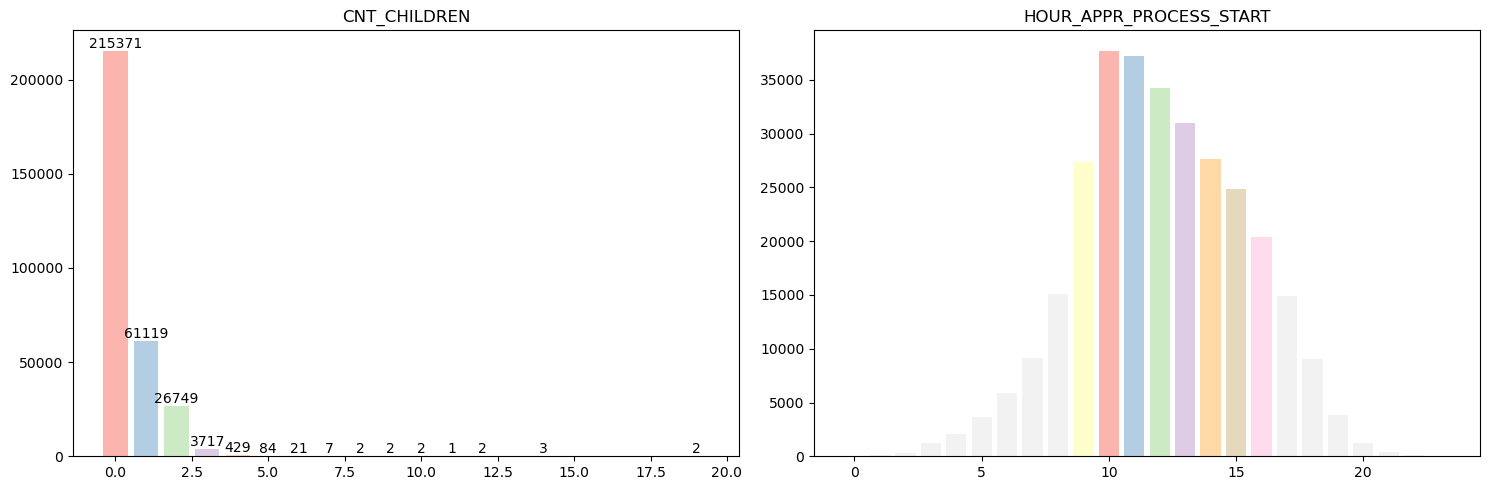

In [9]:
cmap = plt.get_cmap('Pastel1')

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

child_col_counts = application_train['CNT_CHILDREN'].value_counts()
bar_colors = [cmap(i) for i in np.arange(len(child_col_counts))]
child_ax = ax[0].bar(child_col_counts.index, child_col_counts.values, color=bar_colors)
ax[0].bar_label(child_ax)
ax[0].set_title('CNT_CHILDREN')

hour_col_counts = application_train['HOUR_APPR_PROCESS_START'].value_counts()
bar_colors = [cmap(i) for i in np.arange(len(hour_col_counts))]
hour_ax = ax[1].bar(hour_col_counts.index, hour_col_counts.values, color=bar_colors)
# ax[1].bar_label(hour_ax)
ax[1].set_title('HOUR_APPR_PROCESS_START')

plt.tight_layout()
plt.show()  

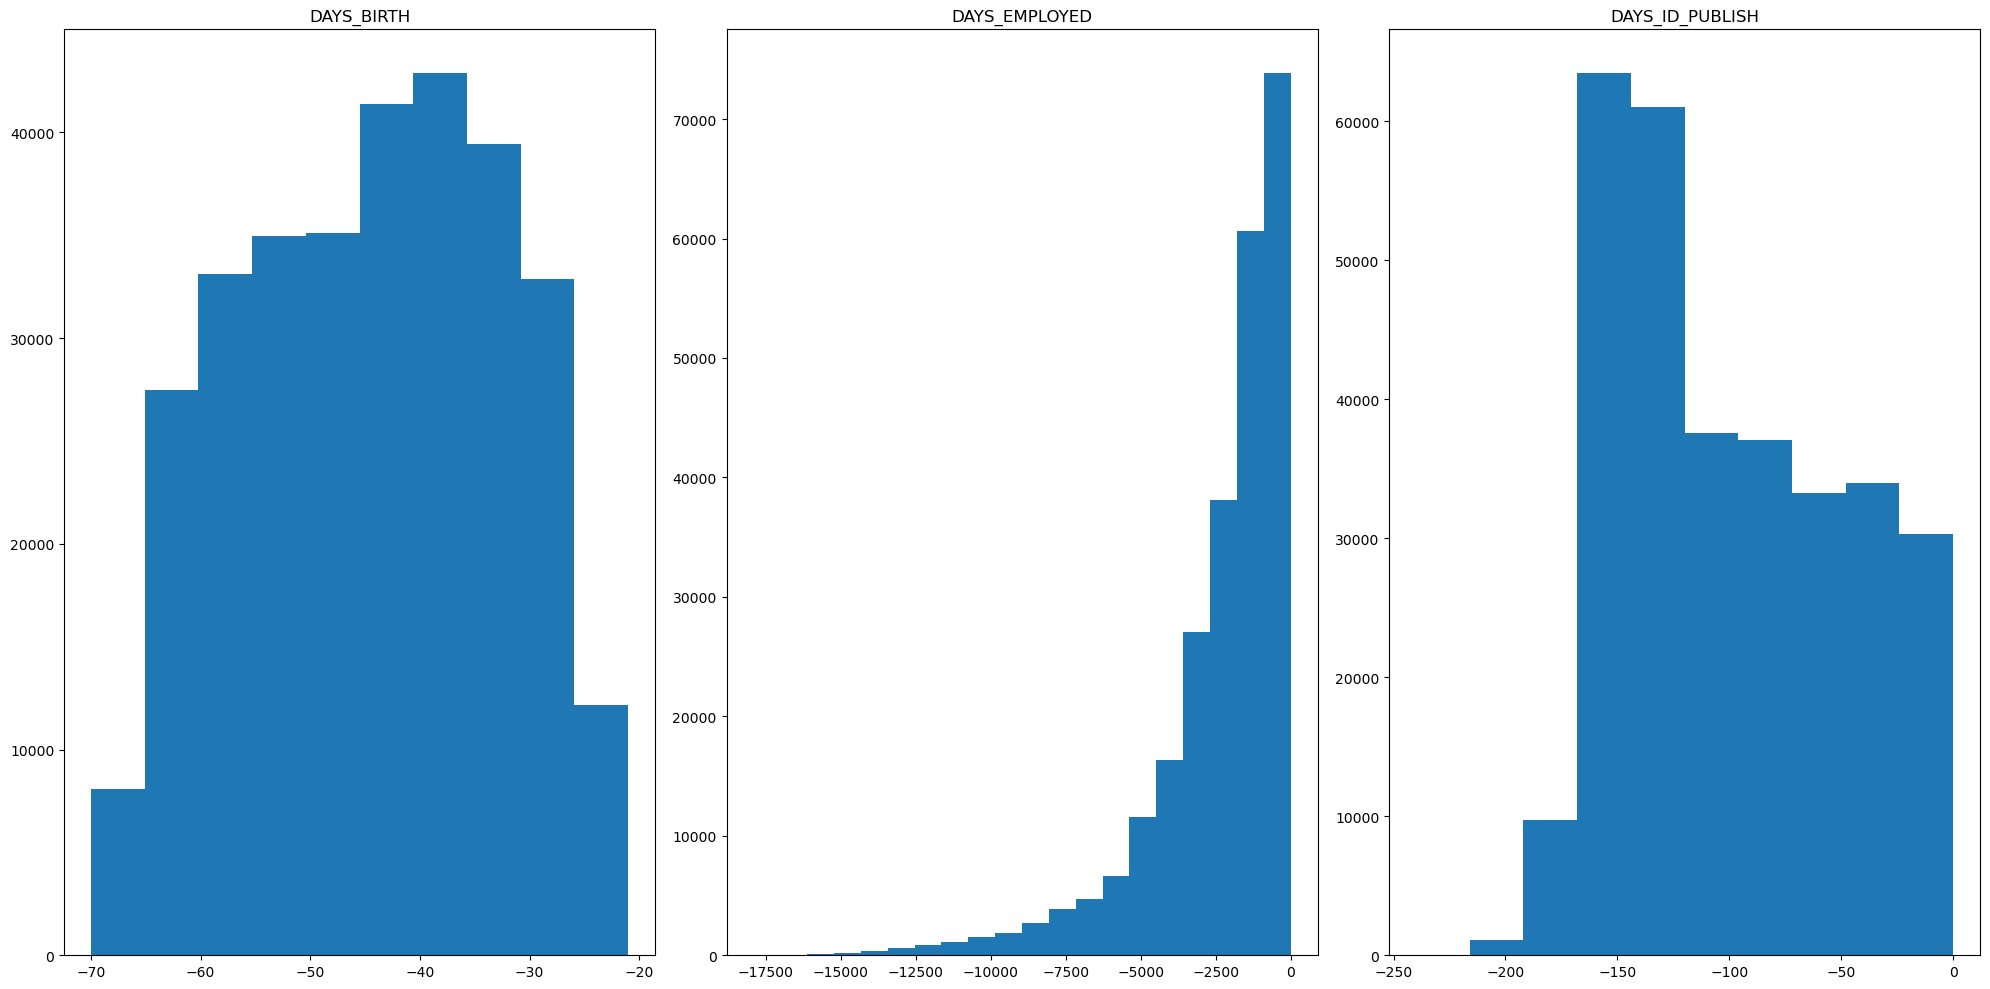

In [10]:
fig, ax = plt.subplots(1, 3, figsize=(20, 10))

# ax[0, 0].hist(application_train['CNT_CHILDREN'], bins=range(application_train['CNT_CHILDREN'].min(), application_train['CNT_CHILDREN'].max()))
ax[0].hist(application_train['DAYS_BIRTH'] // 365)
ax[0].set_title('DAYS_BIRTH')
ax[1].hist(application_train[application_train['DAYS_EMPLOYED'] < 0]['DAYS_EMPLOYED'], bins=20)
ax[1].set_title('DAYS_EMPLOYED')
ax[2].hist(application_train['DAYS_ID_PUBLISH'] // 30)
ax[2].set_title('DAYS_ID_PUBLISH')
# ax[1, 2].hist(application_train['HOUR_APPR_PROCESS_START'])

plt.tight_layout()
plt.show()

In [11]:
for col in int_cols:
    if col in ['SK_ID_CURR', 'TARGET']:
        continue
    if application_train[col].isna().sum() > 0:
        print(f'Column: {col}')
        print(f'Description: {col_des[col_des["Row"] == col]["Description"].iloc[0]}')
        print(f'NaN values: {application_train[col].isna().sum() / num_rows} ({application_train[col].isna().sum()} / {num_rows})')
        print('------------------------')

### Float columns

In [12]:
float_cols = application_train.dtypes[application_train.dtypes == 'float64'].index.tolist()
print(len(float_cols))
float_cols

65


['AMT_INCOME_TOTAL',
 'AMT_CREDIT',
 'AMT_ANNUITY',
 'AMT_GOODS_PRICE',
 'REGION_POPULATION_RELATIVE',
 'DAYS_REGISTRATION',
 'OWN_CAR_AGE',
 'CNT_FAM_MEMBERS',
 'EXT_SOURCE_1',
 'EXT_SOURCE_2',
 'EXT_SOURCE_3',
 'APARTMENTS_AVG',
 'BASEMENTAREA_AVG',
 'YEARS_BEGINEXPLUATATION_AVG',
 'YEARS_BUILD_AVG',
 'COMMONAREA_AVG',
 'ELEVATORS_AVG',
 'ENTRANCES_AVG',
 'FLOORSMAX_AVG',
 'FLOORSMIN_AVG',
 'LANDAREA_AVG',
 'LIVINGAPARTMENTS_AVG',
 'LIVINGAREA_AVG',
 'NONLIVINGAPARTMENTS_AVG',
 'NONLIVINGAREA_AVG',
 'APARTMENTS_MODE',
 'BASEMENTAREA_MODE',
 'YEARS_BEGINEXPLUATATION_MODE',
 'YEARS_BUILD_MODE',
 'COMMONAREA_MODE',
 'ELEVATORS_MODE',
 'ENTRANCES_MODE',
 'FLOORSMAX_MODE',
 'FLOORSMIN_MODE',
 'LANDAREA_MODE',
 'LIVINGAPARTMENTS_MODE',
 'LIVINGAREA_MODE',
 'NONLIVINGAPARTMENTS_MODE',
 'NONLIVINGAREA_MODE',
 'APARTMENTS_MEDI',
 'BASEMENTAREA_MEDI',
 'YEARS_BEGINEXPLUATATION_MEDI',
 'YEARS_BUILD_MEDI',
 'COMMONAREA_MEDI',
 'ELEVATORS_MEDI',
 'ENTRANCES_MEDI',
 'FLOORSMAX_MEDI',
 'FLOORSMIN_M

In [13]:
# Pass normalized columns
col_des = pd.read_excel("D:\Learning\Home_Credit_Default_Risk\data\columns_description.xlsx")
normalized_float_col = col_des[(col_des['Table'] == 'application_{train|test}.csv') & (col_des['Datatype'] == 'float') & (col_des['Special'].str.contains('normalized'))]['Row'].tolist()
print(len(normalized_float_col))
normalized_float_col

<>:2: SyntaxWarning: invalid escape sequence '\L'
<>:2: SyntaxWarning: invalid escape sequence '\L'
C:\Users\ASUS\AppData\Local\Temp\ipykernel_13068\2860375213.py:2: SyntaxWarning: invalid escape sequence '\L'
  col_des = pd.read_excel("D:\Learning\Home_Credit_Default_Risk\data\columns_description.xlsx")


47


['REGION_POPULATION_RELATIVE',
 'EXT_SOURCE_1',
 'EXT_SOURCE_2',
 'EXT_SOURCE_3',
 'APARTMENTS_AVG',
 'BASEMENTAREA_AVG',
 'YEARS_BEGINEXPLUATATION_AVG',
 'YEARS_BUILD_AVG',
 'COMMONAREA_AVG',
 'ELEVATORS_AVG',
 'ENTRANCES_AVG',
 'FLOORSMAX_AVG',
 'FLOORSMIN_AVG',
 'LANDAREA_AVG',
 'LIVINGAPARTMENTS_AVG',
 'LIVINGAREA_AVG',
 'NONLIVINGAPARTMENTS_AVG',
 'NONLIVINGAREA_AVG',
 'APARTMENTS_MODE',
 'BASEMENTAREA_MODE',
 'YEARS_BEGINEXPLUATATION_MODE',
 'YEARS_BUILD_MODE',
 'COMMONAREA_MODE',
 'ELEVATORS_MODE',
 'ENTRANCES_MODE',
 'FLOORSMAX_MODE',
 'FLOORSMIN_MODE',
 'LANDAREA_MODE',
 'LIVINGAPARTMENTS_MODE',
 'LIVINGAREA_MODE',
 'NONLIVINGAPARTMENTS_MODE',
 'NONLIVINGAREA_MODE',
 'APARTMENTS_MEDI',
 'BASEMENTAREA_MEDI',
 'YEARS_BEGINEXPLUATATION_MEDI',
 'YEARS_BUILD_MEDI',
 'COMMONAREA_MEDI',
 'ELEVATORS_MEDI',
 'ENTRANCES_MEDI',
 'FLOORSMAX_MEDI',
 'FLOORSMIN_MEDI',
 'LANDAREA_MEDI',
 'LIVINGAPARTMENTS_MEDI',
 'LIVINGAREA_MEDI',
 'NONLIVINGAPARTMENTS_MEDI',
 'NONLIVINGAREA_MEDI',
 'TOTALA

In [14]:
# Check other float columns
float_cols_left = [i for i in float_cols if i not in normalized_float_col]
float_cols_left

['AMT_INCOME_TOTAL',
 'AMT_CREDIT',
 'AMT_ANNUITY',
 'AMT_GOODS_PRICE',
 'DAYS_REGISTRATION',
 'OWN_CAR_AGE',
 'CNT_FAM_MEMBERS',
 'OBS_30_CNT_SOCIAL_CIRCLE',
 'DEF_30_CNT_SOCIAL_CIRCLE',
 'OBS_60_CNT_SOCIAL_CIRCLE',
 'DEF_60_CNT_SOCIAL_CIRCLE',
 'DAYS_LAST_PHONE_CHANGE',
 'AMT_REQ_CREDIT_BUREAU_HOUR',
 'AMT_REQ_CREDIT_BUREAU_DAY',
 'AMT_REQ_CREDIT_BUREAU_WEEK',
 'AMT_REQ_CREDIT_BUREAU_MON',
 'AMT_REQ_CREDIT_BUREAU_QRT',
 'AMT_REQ_CREDIT_BUREAU_YEAR']

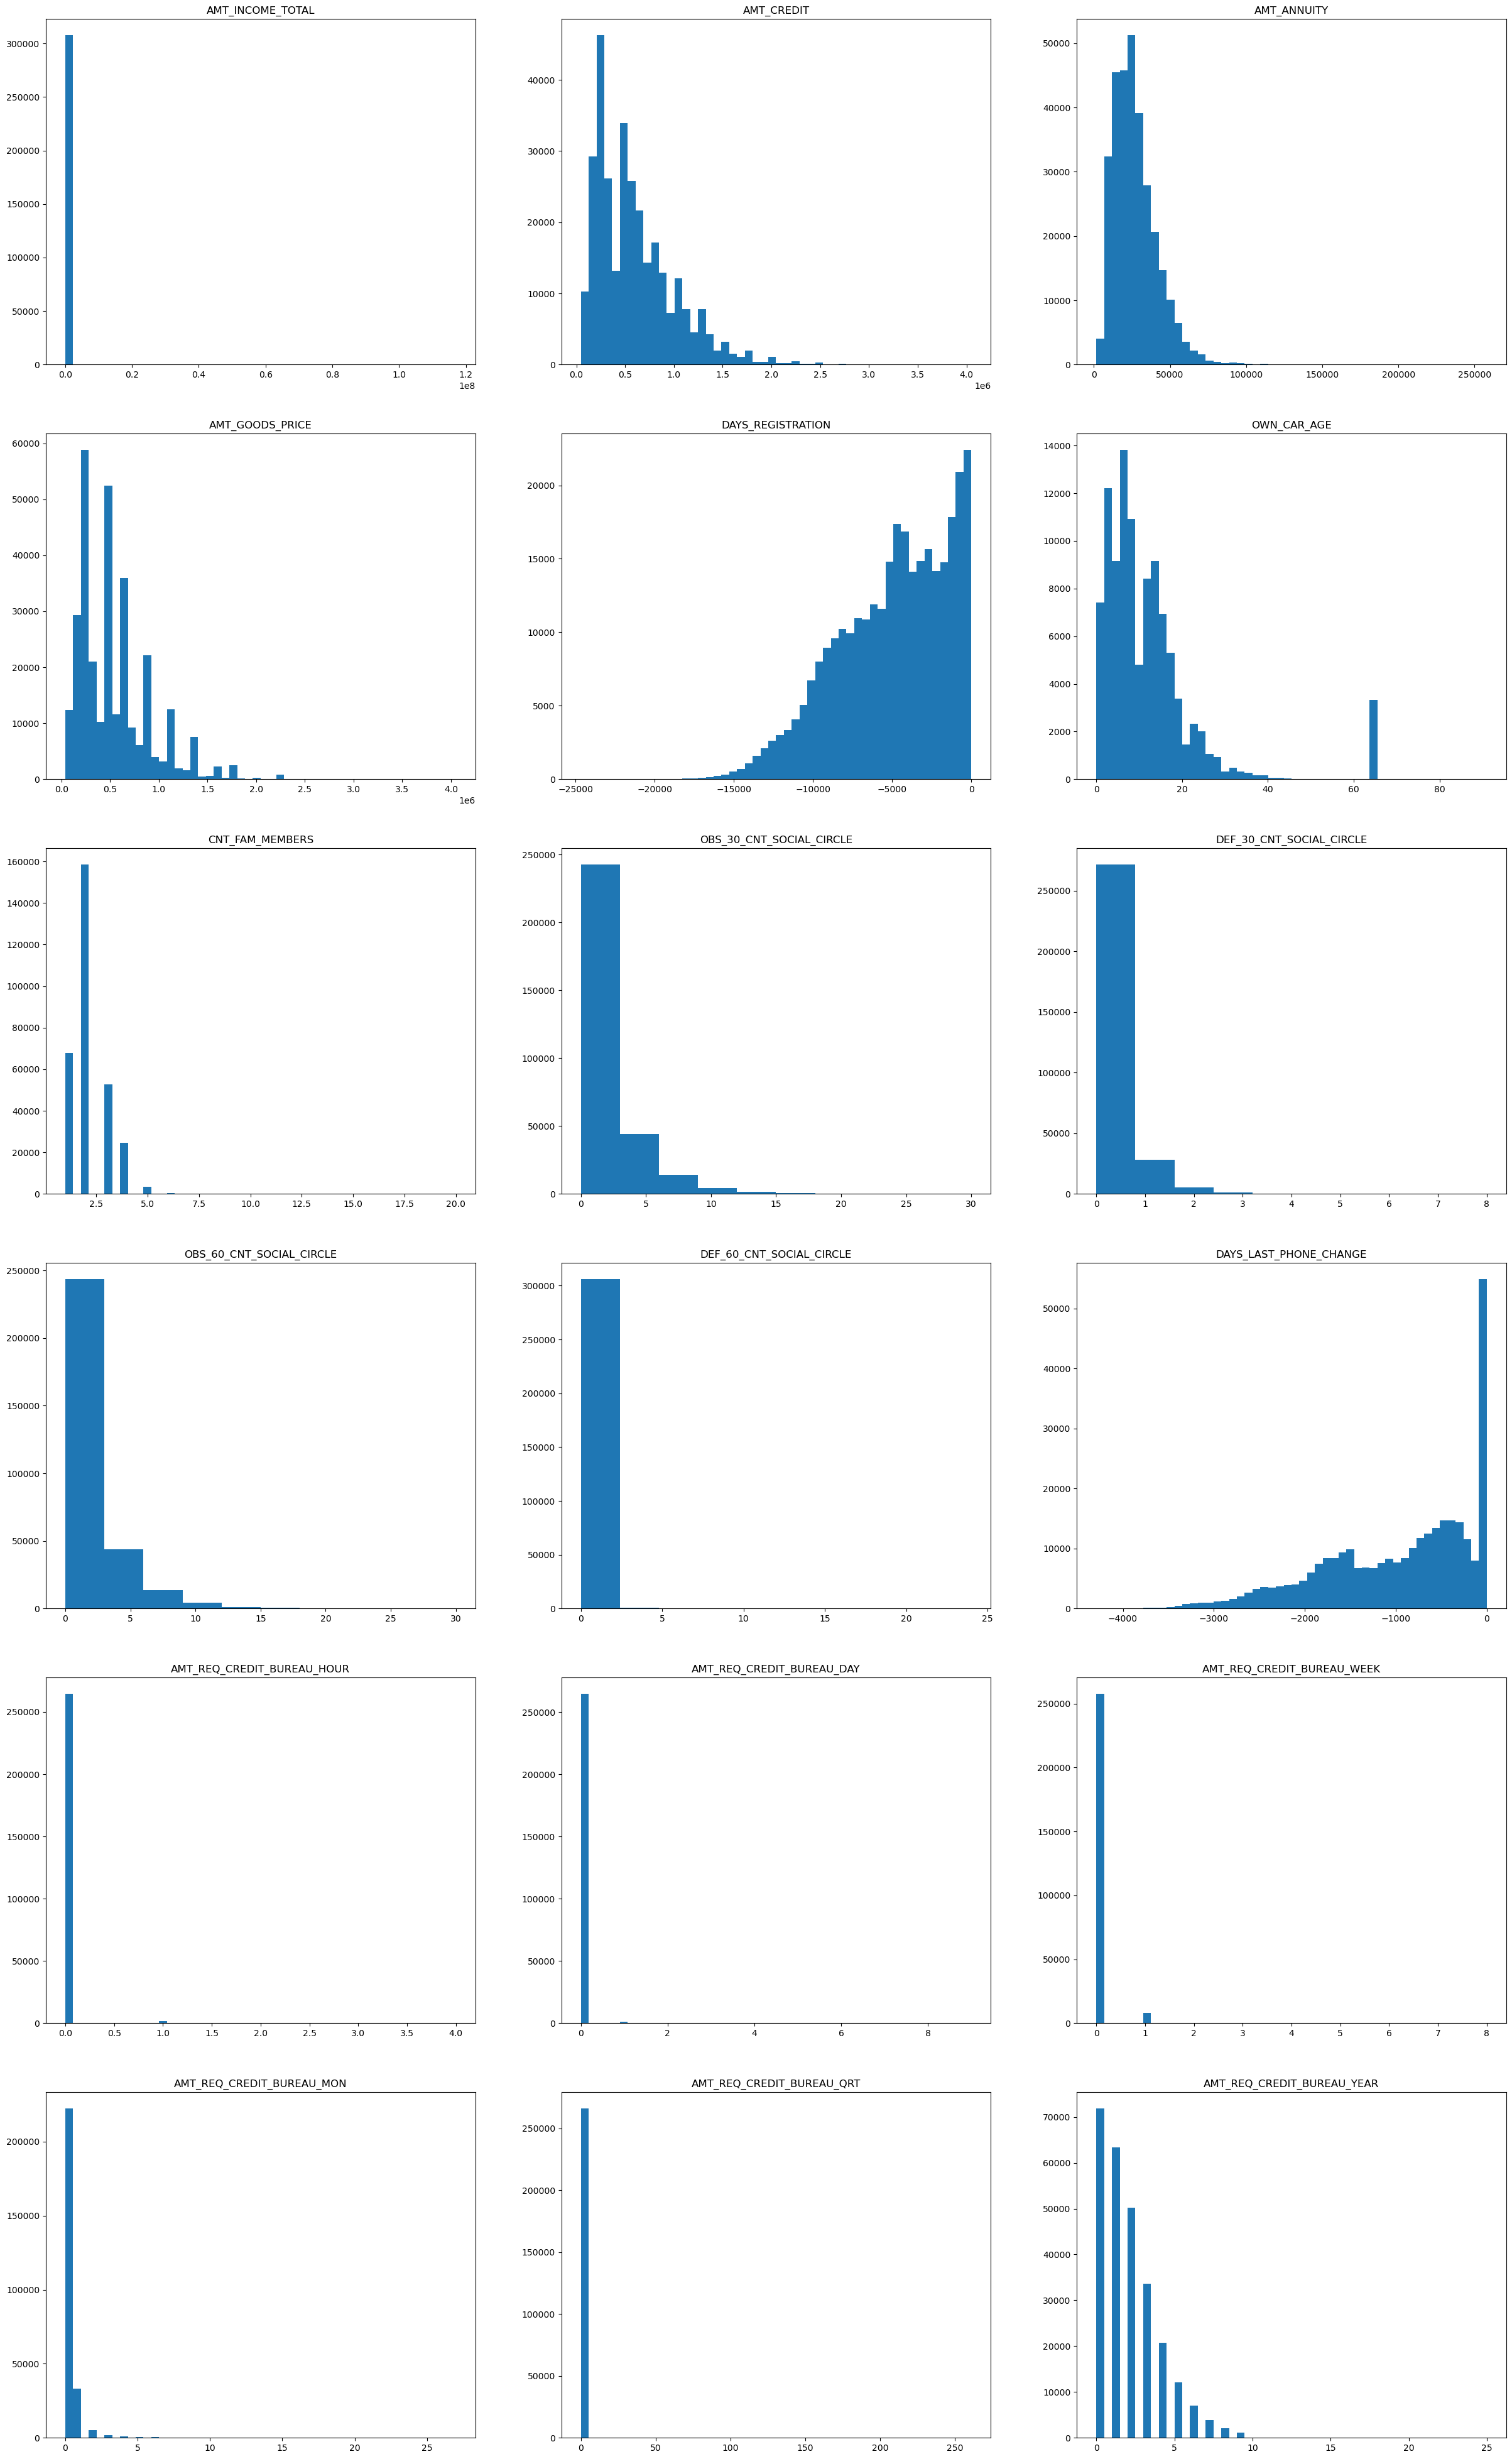

In [15]:
# Check the columns' distribution
fig, ax = plt.subplots(6, 3, figsize = (30, 50))

for i in range(len(float_cols_left)):
    # val_counts = application_train[col].value_counts()
    if float_cols_left[i] in ['OBS_30_CNT_SOCIAL_CIRCLE', 'DEF_30_CNT_SOCIAL_CIRCLE', 'OBS_60_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE']:
        sliced_df = application_train[application_train[float_cols_left[i]] <= 30][float_cols_left[i]]
        ax[i // 3, i % 3].hist(sliced_df)
    else:
        sliced_df = application_train[float_cols_left[i]]
        ax[i // 3, i % 3].hist(sliced_df, bins=50)
    
    ax[i // 3, i % 3].set_title(float_cols_left[i])

# 90% right-tailed number of rows, if two-tailed just divide by 2
def get_right_tailed_perc(df, perc):
    return perc * df.shape[0] // 100

Max Income: 117000000.0
Min Income: 25650.0
Difference between the maximum and minimum income: 116974350.0
80% right-tailed number of rows: 285985
AMT_INCOME_TOTAL
135000.000    35750
112500.000    31019
90000.000     22483
67500.000     11147
81000.000      6001
126000.000     4668
121500.000     3848
99000.000      3633
103500.000     3330
76500.000      3146
144000.000     3123
117000.000     2390
54000.000      2319
72000.000      2187
45000.000      2043
108000.000     1946
94500.000      1747
85500.000      1514
130500.000     1256
58500.000      1182
63000.000      1145
139500.000      834
49500.000       738
40500.000       361
36000.000       343
31500.000       184
83250.000       150
78750.000       137
56250.000       136
60750.000       131
74250.000       110
87750.000       110
69750.000       103
101250.000      102
65250.000        98
47250.000        95
105750.000       90
123750.000       90
51750.000        89
128250.000       87
110250.000       76
96750.000       

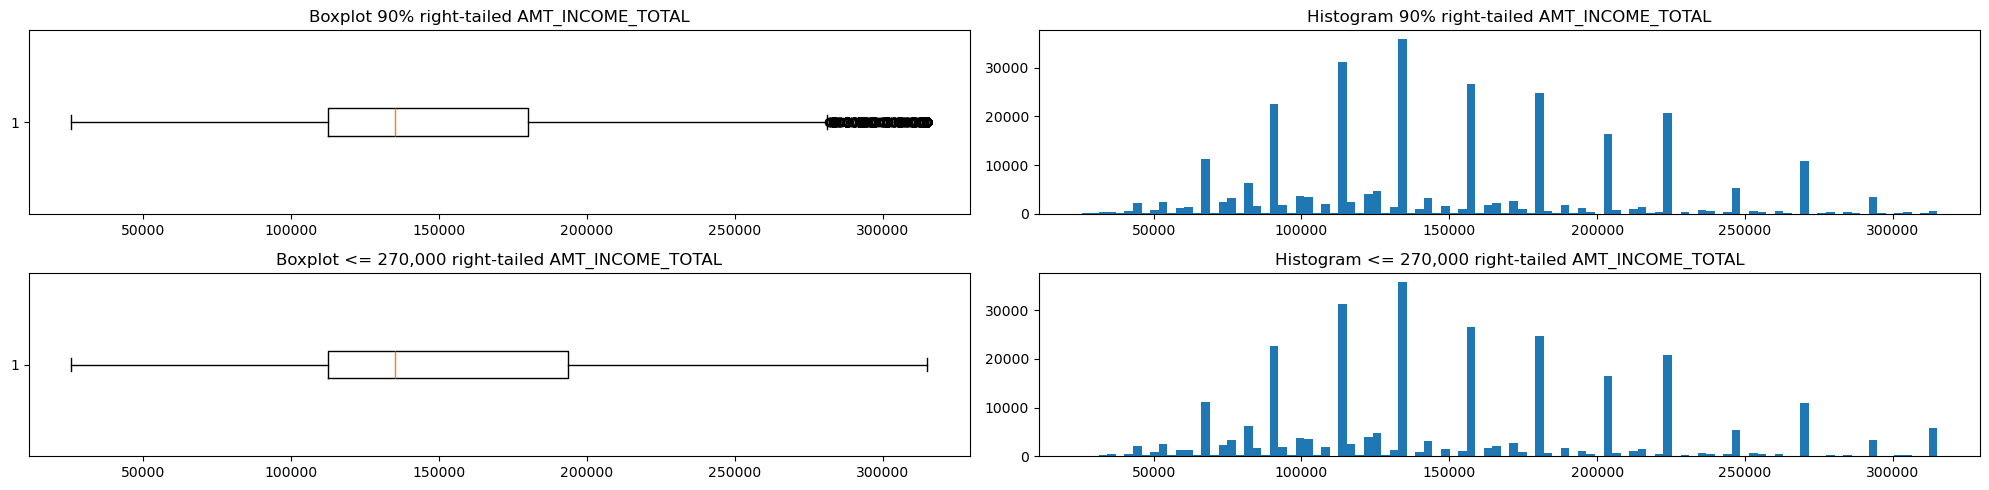

In [19]:
# AMT_INCOME_TOTAL
sorted_income_total = application_train['AMT_INCOME_TOTAL'].sort_values()
print(f'Max Income: {sorted_income_total.iloc[-1]}')
print(f'Min Income: {sorted_income_total.iloc[0]}')
print(f'Difference between the maximum and minimum income: {sorted_income_total.iloc[-1] - sorted_income_total.iloc[0]}')

right_tailed_80 = get_right_tailed_perc(application_train, 93)
print(f'80% right-tailed number of rows: {right_tailed_80}')

print(application_train['AMT_INCOME_TOTAL'].sort_values().iloc[:get_right_tailed_perc(application_train, 50)].value_counts())
print(f'90% value: {sorted_income_total.iloc[right_tailed_80]}')

fig, ax = plt.subplots(2, 2, figsize=(20, 5))
ax[0, 0].boxplot(sorted_income_total.iloc[:right_tailed_80], vert=False)
ax[0, 0].set_title("Boxplot 90% right-tailed AMT_INCOME_TOTAL")
ax[0, 1].hist(sorted_income_total.iloc[:right_tailed_80], bins=100)
ax[0, 1].set_title("Histogram 90% right-tailed AMT_INCOME_TOTAL")
ax[1, 0].boxplot(sorted_income_total[sorted_income_total <= sorted_income_total.iloc[right_tailed_80]], vert=False)
ax[1, 0].set_title("Boxplot <= 270,000 right-tailed AMT_INCOME_TOTAL")
ax[1, 1].hist(sorted_income_total[sorted_income_total <= sorted_income_total.iloc[right_tailed_80]], bins=100)
ax[1, 1].set_title("Histogram <= 270,000 right-tailed AMT_INCOME_TOTAL")
plt.tight_layout()
plt.show()

Min credit value: 45000.0
Max credit value: 4050000.0
Percentage of chosen rows: 96.50223894429793


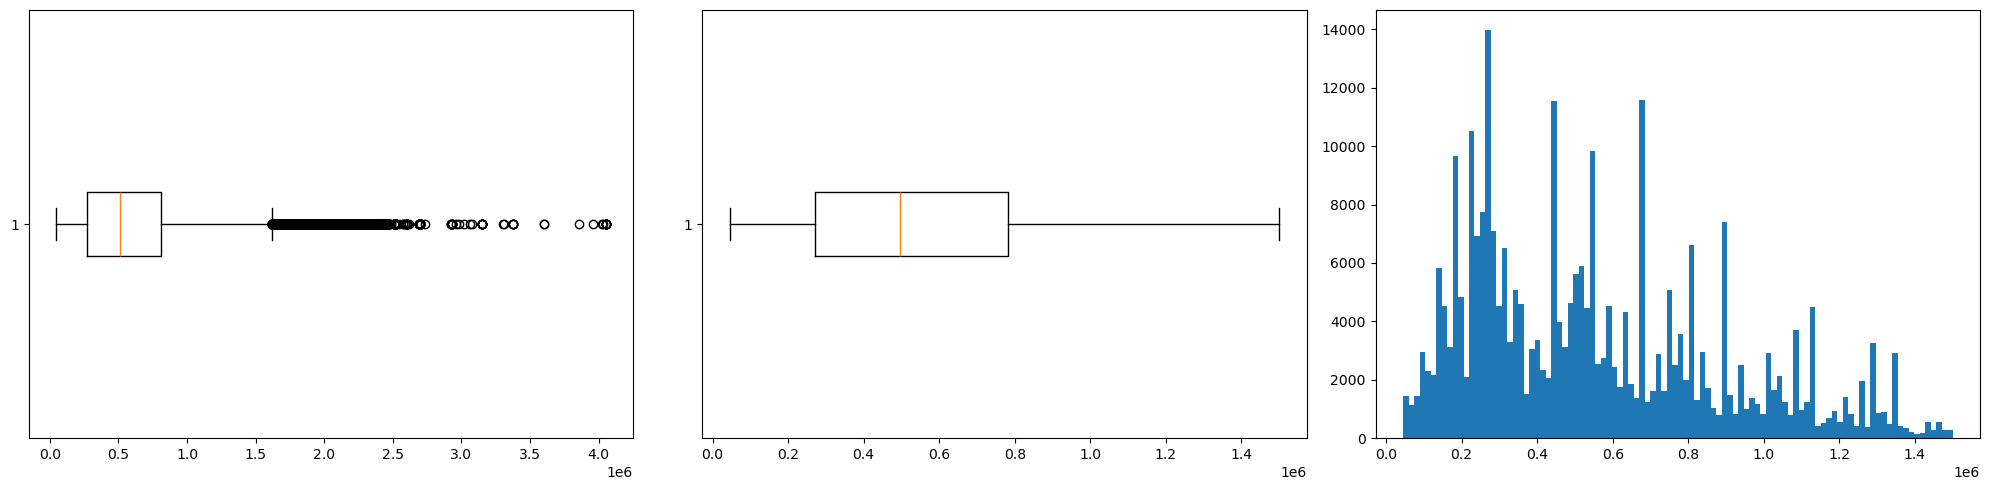

In [80]:
# Check AMT_CREDIT
amt_credit_sorted = application_train['AMT_CREDIT'].sort_values()
print(f'Min credit value: {amt_credit_sorted.iloc[0]}')
print(f'Max credit value: {amt_credit_sorted.iloc[-1]}')

# right_tailed_80 = get_right_tailed_perc(application_train, 99)
chosen_limit = 1500000
print(f'Percentage of chosen rows: {application_train[application_train["AMT_CREDIT"] <= chosen_limit].shape[0] / application_train.shape[0] * 100}')
fig, ax = plt.subplots(1, 3, figsize=(20, 5))
ax[0].boxplot(amt_credit_sorted, vert=False)
ax[1].boxplot(amt_credit_sorted[amt_credit_sorted <= chosen_limit], vert=False)
ax[2].hist(amt_credit_sorted[amt_credit_sorted <= chosen_limit], bins=100)
plt.tight_layout()
plt.show()

Min annuity value: 1615.5
Max annuity value: 258025.5
98.99804552209926


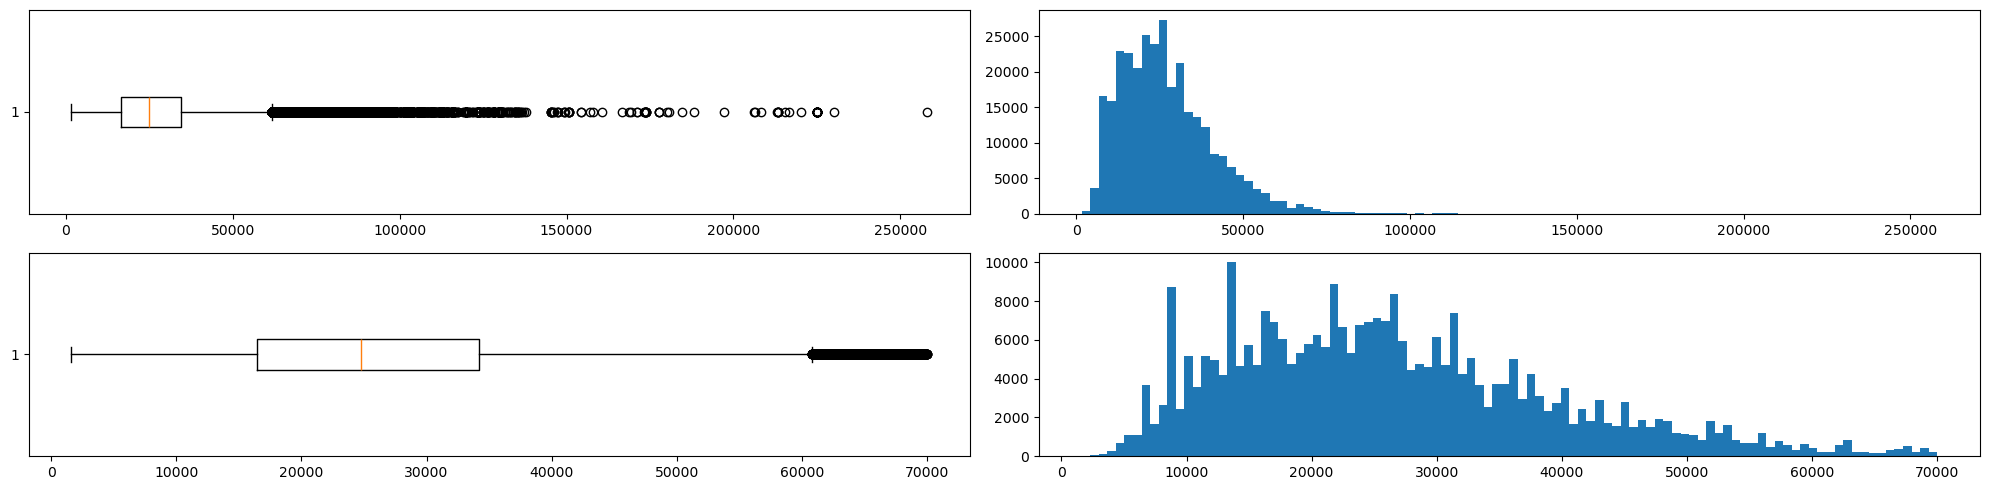

In [70]:
# Check AMT_ANNUITY
sorted_annuity = application_train['AMT_ANNUITY'].sort_values().dropna()
print(f'Min annuity value: {sorted_annuity.iloc[0]}')
print(f'Max annuity value: {sorted_annuity.max()}')

# Check if the monthly responsibility is greater than the credit amount, which is not possible
application_train[application_train['AMT_ANNUITY'] > application_train['AMT_CREDIT']]

# Check the NaN values in AMT_ANNUITY
application_train['AMT_ANNUITY'].isna().sum()

print(sorted_annuity[sorted_annuity <= 70000].shape[0] / sorted_annuity.shape[0] * 100)

fig, ax = plt.subplots(2, 2, figsize=(20, 5))
ax[0, 0].boxplot(sorted_annuity, vert=False)
ax[0, 1].hist(sorted_annuity, bins=100)
ax[1, 0].boxplot(sorted_annuity[sorted_annuity <= 70000], vert=False)
ax[1, 1].hist(sorted_annuity[sorted_annuity <= 70000], bins=100)
plt.tight_layout()
plt.show()

NaN values: 278
Min goods price value: 40500.0
Max goods price value: 4050000.0
Percentage of chosen rows: 97.46578171187372


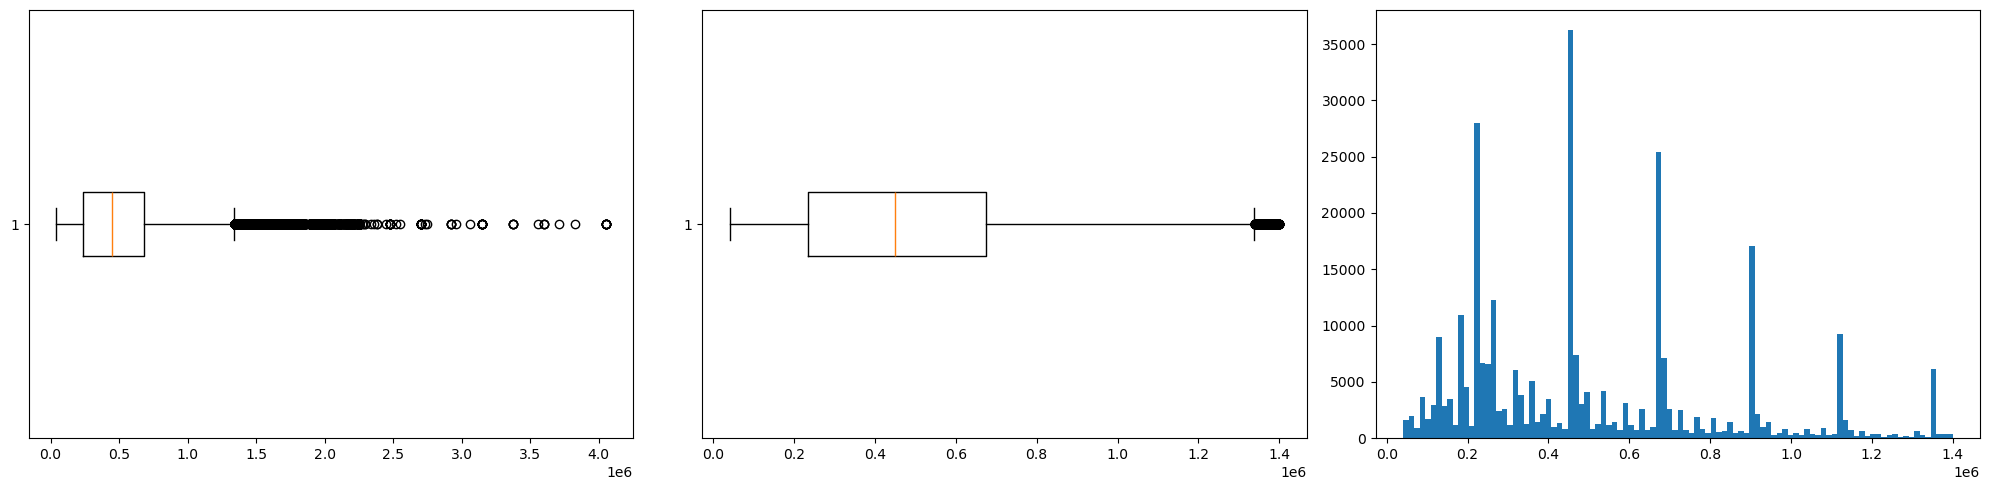

In [82]:
# Check AMT_GOODS_PRICE
print(f'NaN values: {application_train["AMT_GOODS_PRICE"].isna().sum()}')
sorted_goods_price = application_train['AMT_GOODS_PRICE'].sort_values().dropna()
print(f'Min goods price value: {sorted_goods_price.iloc[0]}')
print(f'Max goods price value: {sorted_goods_price.max()}')

chosen_limit = 1400000
print(f'Percentage of chosen rows: {application_train[application_train["AMT_GOODS_PRICE"] <= chosen_limit].shape[0] / application_train.shape[0] * 100}')
fig, ax = plt.subplots(1, 3, figsize=(20, 5))
ax[0].boxplot(sorted_goods_price, vert=False)
ax[1].boxplot(sorted_goods_price[sorted_goods_price <= chosen_limit], vert=False)
ax[2].hist(sorted_goods_price[sorted_goods_price <= chosen_limit], bins=100)
plt.tight_layout()
plt.show()

Farthest application day: -24672.0 --> 67.59452054794521 years
Closest application day: 0.0
Number of rows with application day exceeding 15000 days (41 years): 1219
Percentage of rows with application day exceeding 15000 days (41 years): 0.4%


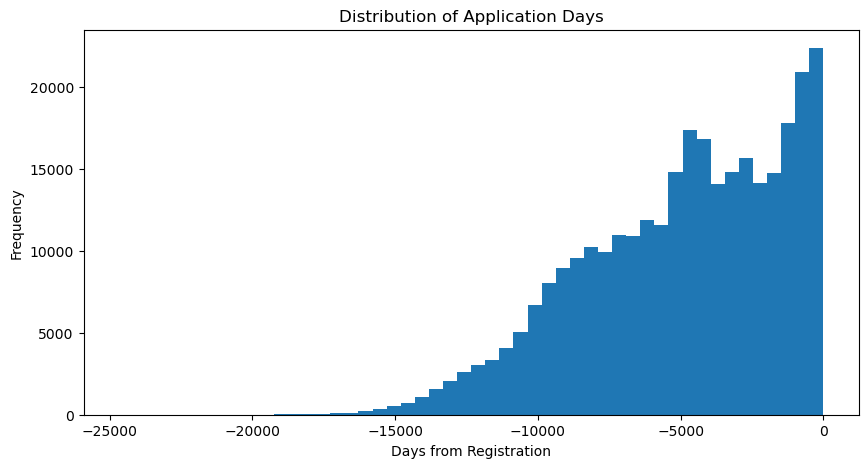

In [71]:
# Days from registration
print(f"Farthest application day: {application_train['DAYS_REGISTRATION'].min()} --> {-application_train['DAYS_REGISTRATION'].min() / 365} years")
print(f"Closest application day: {application_train['DAYS_REGISTRATION'].max()}")

print(f'Number of rows with application day exceeding 15000 days (41 years): {application_train[application_train['DAYS_REGISTRATION'] <= -15000]['SK_ID_CURR'].count()}')
print(f'Percentage of rows with application day exceeding 15000 days (41 years): {round(application_train[application_train['DAYS_REGISTRATION'] <= -15000]['SK_ID_CURR'].count() / application_train.shape[0] * 100, 2)}%')

plt.figure(figsize=(10, 5))
plt.hist(application_train['DAYS_REGISTRATION'], bins=50)
plt.xlabel("Days from Registration")
plt.ylabel("Frequency")
plt.title("Distribution of Application Days")
plt.show()

In [18]:
# Check CNT_FAM_MEMBERS
print(application_train['CNT_FAM_MEMBERS'].value_counts())
print('-------------------------------')

# Check age of the client's car
print(application_train['OWN_CAR_AGE'].value_counts().sort_index())
print('-------------------------------')

# Check OBS_30_CNT_SOCIAL_CIRCLE
print(application_train[application_train['OBS_30_CNT_SOCIAL_CIRCLE'] <= 100]['OBS_30_CNT_SOCIAL_CIRCLE'].value_counts().sort_index())
print('-------------------------------')

# Check DEF_30_CNT_SOCIAL_CIRCLE
print(application_train[application_train['DEF_30_CNT_SOCIAL_CIRCLE'] <= 100]['DEF_30_CNT_SOCIAL_CIRCLE'].value_counts().sort_index())
print(application_train[application_train['DEF_30_CNT_SOCIAL_CIRCLE'] > 10][['OBS_30_CNT_SOCIAL_CIRCLE','DEF_30_CNT_SOCIAL_CIRCLE']])
print('-------------------------------')

# Check OBS_60_CNT_SOCIAL_CIRCLE
print(application_train['OBS_60_CNT_SOCIAL_CIRCLE'].value_counts().sort_index())
print('-------------------------------')

# Check DEF_60_CNT_SOCIAL_CIRCLE
print(application_train['DEF_60_CNT_SOCIAL_CIRCLE'].value_counts().sort_index())
print(application_train[application_train['DEF_60_CNT_SOCIAL_CIRCLE'] > 10][['OBS_60_CNT_SOCIAL_CIRCLE','DEF_60_CNT_SOCIAL_CIRCLE']])
print('-------------------------------')

CNT_FAM_MEMBERS
2.0     158357
1.0      67847
3.0      52601
4.0      24697
5.0       3478
6.0        408
7.0         81
8.0         20
9.0          6
10.0         3
14.0         2
12.0         2
20.0         2
16.0         2
13.0         1
15.0         1
11.0         1
Name: count, dtype: int64
-------------------------------
OWN_CAR_AGE
0.0     2134
1.0     5280
2.0     5852
3.0     6370
4.0     5557
5.0     3595
6.0     6382
7.0     7424
8.0     5887
9.0     5020
10.0    4806
11.0    4161
12.0    4257
13.0    4566
14.0    4594
15.0    3580
16.0    3355
17.0    2899
18.0    2418
19.0    1864
20.0    1527
21.0    1462
22.0    1250
23.0    1067
24.0    1150
25.0     865
26.0     580
27.0     483
28.0     542
29.0     397
30.0     326
31.0     267
32.0     208
33.0     132
34.0     183
35.0     157
36.0     124
37.0      75
38.0      97
39.0      78
40.0      85
41.0      58
42.0      42
43.0      19
44.0      21
45.0      11
46.0       5
47.0       1
48.0       1
49.0       6
50.0     

### Correlations between columns
Phải kiểm tra xem liệu có cột nào correlate, các cột nào mà ý nghĩa vớ vẩn thì bỏ đi

# Data Preprocessing Pipeline
## application_{train|test}

- **String Columns**:   
    - Hot Encoding columns (phải xử lý các trường hợp bị NaN nữa): NAME_CONTRACT_TYPE, NAME_TYPE_SUITE, NAME_INCOME_TYPE, NAME_FAMILY_STATUS, NAME_HOUSING_TYPE, FONDKAPREMONT_MODE, HOUSETYPE_MODE, WALLSMATERIAL_MODE
    - Ordered columns:
        - CODE_GENDER: {'F': 0, 'M': 1, 'XNA': 2}
        - FLAG_OWN_CAR: {'N': 0, 'Y': 1}
        - FLAG_OWN_REALTY: {'N': 0, 'Y': 1}
        - NAME_EDUCATION_TYPE: {'Lower secondar': 0, 'Secondary / secondary special': 1, 'Incomplete higher': 2, 'Higher education': 3, 'Academic degree': 4}
        - WEEKDAY_APPR_PROCESS_START: {'MONDAY': 0, 'TUESDAY': 1, 'WEDNESDAY': 2, 'THURSDAY': 3, 'FRIDAY': 4, 'SATURDAY': 5, 'SUNDAY': 6}
        - EMERGENCYSTATE_MODE: {'No': 0, 'Yes': 1}
- **Int columns**: Flag columns stay the same, only process CNT_CHILDREN, HOUR_APPR_PROCESS_START, DAYS_BIRTH, DAYS_EMPLOYED, DAYS_ID_PUBLISH
    - CNT_CHILDREN: stays the same
    - HOUR_APPR_PROCESS_START: convert into sin/cosine to simulate the cycle characteristic.
    - DAYS_EMPLOYED has 55374 rows that have strange values. THis makes up for 1/5 of the rows. When taking only values that are < 0, the distribution makes much more sense.
    - DAYS_BIRTH / 365 to calculate the years
    - DAYS_EMPLOYED, DAYS_ID_PUBLISH / 30 to calculate the months
- **Float columns**:
    - 'REGION_POPULATION_RELATIVE', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'YEARS_BEGINEXPLUATATION_AVG', 'YEARS_BUILD_AVG', 'COMMONAREA_AVG', 'ELEVATORS_AVG', 'ENTRANCES_AVG', 'FLOORSMAX_AVG', 'FLOORSMIN_AVG', 'LANDAREA_AVG', 'LIVINGAPARTMENTS_AVG', 'LIVINGAREA_AVG', 'NONLIVINGAPARTMENTS_AVG', 'NONLIVINGAREA_AVG', 'APARTMENTS_MODE', 'BASEMENTAREA_MODE', 'YEARS_BEGINEXPLUATATION_MODE', 'YEARS_BUILD_MODE', 'COMMONAREA_MODE', 'ELEVATORS_MODE', 'ENTRANCES_MODE', 'FLOORSMAX_MODE', 'FLOORSMIN_MODE', 'LANDAREA_MODE', 'LIVINGAPARTMENTS_MODE', 'LIVINGAREA_MODE', 'NONLIVINGAPARTMENTS_MODE', 'NONLIVINGAREA_MODE', 'APARTMENTS_MEDI', 'BASEMENTAREA_MEDI', 'YEARS_BEGINEXPLUATATION_MEDI', 'YEARS_BUILD_MEDI', 'COMMONAREA_MEDI', 'ELEVATORS_MEDI', 'ENTRANCES_MEDI', 'FLOORSMAX_MEDI', 'FLOORSMIN_MEDI', 'LANDAREA_MEDI', 'LIVINGAPARTMENTS_MEDI', 'LIVINGAREA_MEDI', 'NONLIVINGAPARTMENTS_MEDI', 'NONLIVINGAREA_MEDI', 'TOTALAREA_MODE': normalized, hidden data columns, doesn't need further processing
    - 'AMT_INCOME_TOTAL': only take values that are <= 285,000. Scale
    - 'AMT_CREDIT': only take values that are <= 2,000,000. Scale
    - 'AMT_ANNUITY': only take values that are <= 70,000. Scale
    - 'AMT_GOODS_PRICE': only take values that are <= 1,400,000. Scale
    - 'CNT_FAM_MEMBERS': turn its datatype to int and try to get rid of cases that have more than 15 people to see if it has better performance. Should be scaled.
    - 'DAYS_REGISTRATION': try cutting off those that exceed -15000 days (41 years). Should be scaled.
    - 'OWN_CAR_AGE': change its datatype into int. Should be normalized
    - 'OBS_30_CNT_SOCIAL_CIRCLE': get rid of outliers that are > 100. Turn its datatype into int. Scale
    - 'DEF_30_CNT_SOCIAL_CIRCLE': get rid of outliers that are > 100. Turn its datatype into int. Scale. Calculate the percentage of actual defaulted social circle compared to possible defaulted social circle of client by DEF_30 / OBS_30 * 100
    - 'OBS_60_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE': similar to OBS_30, DEF_30
    

